In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.patches as mpl_patches
import matplotlib.ticker as ticker

In [2]:
df=pd.read_table('LeafMg_834_Genotype.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,Chr5_21390834,Chr5_21392702,Chr5_282011
0,88,CYR,France,47.4000,0.683333,CS76790,leaf,France_leaf,4513.790113,0,0,1
1,108,LDV-18,France,48.5167,-4.066670,CS77013,leaf,France_leaf,4444.244161,0,0,1
2,139,LDV-46,France,48.5167,-4.066670,CS77014,leaf,France_leaf,4548.751871,0,0,1
3,159,MAR2-3,France,47.3500,3.933330,CS77070,leaf,France_leaf,4808.545837,0,0,1
4,265,PYL-6,France,44.6500,-1.166670,CS77198,leaf,France_leaf,4103.189376,1,0,1


alt: 62
ref: 735
['0', '1']


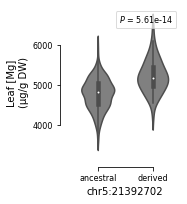

In [4]:
boxprops = {'edgecolor': 'black', 'linewidth': 0.5, 'facecolor': 'grey'}
lineprops = {'color': 'k', 'linewidth': 0.5}
boxplot_kwargs = dict({'boxprops': boxprops, 'medianprops': lineprops,
                       'whiskerprops': lineprops, 'capprops': lineprops,
                       'width': 0.6})

alt=df[df['Chr5_21392702'] == '1']
ref=df[df['Chr5_21392702'] == '0']
print('alt: ' + str(alt.shape[0]) + '\nref: ' + str(ref.shape[0]))

Order=[]
if alt.shape[0] > ref.shape[0]:
    Order=['1','0']
elif alt.shape[0] < ref.shape[0]:
    Order=['0','1']
print(Order)

@ticker.FuncFormatter
def major_formatter(x, pos):
    y = x /1000000
    return "%.0f" % y
cm = 1/2.54
plt.figure(figsize=(5*cm,7*cm))
ax=sns.violinplot(x='Chr5_21392702', 
            y='Mg25',
            color='grey',
            data=df,
            order=Order,
            linewidth=1.5,
            fliersize=0,
            **boxplot_kwargs)
r,p = mannwhitneyu(alt['Mg25'],ref['Mg25'])
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                 lw=0, alpha=0)] * 2
labels=[]
labels.append(r"$P$ = {:.2e}".format(p))
plt.legend(handles, labels, loc='best', fontsize=8, 
      fancybox=True, framealpha=0.7, 
      handlelength=0, handletextpad=0)
ax.set_xlabel('chr5:21392702',fontsize=10)
ax.set_xticklabels(['ancestral', 'derived'])
plt.ylabel('Leaf [Mg] \n(µg/g DW)',fontsize=10)

sns.despine(trim=True,offset=10)
plt.tick_params(labelsize=8)
plt.savefig("fig4b.pdf", format="pdf",bbox_inches="tight",facecolor='w')